# OUPUTED FUZZY PIPELINE FOR THRESHOLD 90,95 AND 98

In [9]:
from fuzzywuzzy import fuzz
import pandas as pd
import re

# -----------------------------
# Cleaning utilities
# -----------------------------
def clean_name(name):
    if pd.isna(name):
        return ""
    name = str(name).lower().strip()

    patterns = [
        r"\bsdn\.?\s*bhd\.?\b",
        r"\bsendiran\s*berhad\b",
        r"\bs/b\b",
        r"\bsdn\b",
        r"\bbhd\b",
    ]
    for p in patterns:
        name = re.sub(p, "", name)

    name = re.sub(r"[./():,\-&@]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

def clean_employer_id(eid):
    if pd.isna(eid):
        return ""
    eid = str(eid).lower().strip()
    eid = re.sub(r"[.,()/\-]", "", eid)
    return eid

# -----------------------------
# Fuzzy similarity
# -----------------------------
def fuzzy_score(name1, name2):
    return fuzz.ratio(clean_name(name1), clean_name(name2))

# -----------------------------
# Main matching function
# -----------------------------
def match_and_merge(df, fuzzy_threshold):

    merged_data = []
    seen_global = set()

    # Apply cleaning ONCE
    df["E_NAME_CLEAN"] = df["E NAME"].apply(clean_name)
    df["E_NO_CLEAN"]   = df["E NO"].apply(clean_employer_id)

    for state, group in df.groupby("STATE"):
        group = group.reset_index(drop=True)

        for i in range(len(group)):
            if (state, i) in seen_global:
                continue

            current_row = group.iloc[i]
            matches = [current_row]
            seen_global.add((state, i))

            fuzzy_scores = []

            for j in range(i + 1, len(group)):
                if (state, j) in seen_global:
                    continue

                candidate_row = group.iloc[j]

                # Skip merging ONLY if BOTH IDs are empty
                if current_row["E_NO_CLEAN"] == "" and candidate_row["E_NO_CLEAN"] == "":
                    continue

                fz = fuzzy_score(
                    current_row["E_NAME_CLEAN"],
                    candidate_row["E_NAME_CLEAN"]
                )

                # ID match only if both IDs exist
                id_match = (
                    current_row["E_NO_CLEAN"] != "" and
                    candidate_row["E_NO_CLEAN"] != "" and
                    current_row["E_NO_CLEAN"] == candidate_row["E_NO_CLEAN"]
                )

                # Merge if names similar or IDs match
                if fz >= fuzzy_threshold or id_match:
                    matches.append(candidate_row)
                    seen_global.add((state, j))
                    fuzzy_scores.append(fz)

            # -----------------------------
            # Build output row
            # -----------------------------
            if len(matches) > 1:
                similar_df = pd.DataFrame(matches)

                merged_row = {
                    "STATE": state,
                    "E NO": ", ".join(sorted(set(similar_df["E NO"].astype(str)))),
                    "E NAME": ", ".join(sorted(set(similar_df["E NAME"].astype(str)))),
                    "KOD": ", ".join(sorted(set(similar_df["KOD"].astype(str)))),
                    "BP 2024_01": similar_df["BP 2024_01"].sum(),
                    "BP 2024_02": similar_df["BP 2024_02"].sum(),
                    "BP 2024_03": similar_df["BP 2024_03"].sum(),
                    "BP 2024_04": similar_df["BP 2024_04"].sum(),
                    "BP 2024_05": similar_df["BP 2024_05"].sum(),
                    "BP 2024_06": similar_df["BP 2024_06"].sum(),
                    "MERGE_COUNT": len(similar_df),
                    "MIN_FUZZY": min(fuzzy_scores) if fuzzy_scores else 100,
                    "MAX_FUZZY": max(fuzzy_scores) if fuzzy_scores else 100,
                    "FUZZY_THRESHOLD_USED": fuzzy_threshold
                }
                merged_data.append(merged_row)

            else:
                row_dict = current_row.to_dict()
                row_dict.update({
                    "MERGE_COUNT": 1,
                    "MIN_FUZZY": 100,
                    "MAX_FUZZY": 100,
                    "FUZZY_THRESHOLD_USED": fuzzy_threshold
                })
                merged_data.append(row_dict)

    return pd.DataFrame(merged_data)

# -----------------------------
# 🔬 Threshold experiments
# -----------------------------
thresholds = [90, 95, 98]

for t in thresholds:
    print(f"\n🚀 Running fuzzy matching with threshold = {t}")
    merged_df = match_and_merge(df, fuzzy_threshold=t)
    merged_df.to_excel(f"merged_fuzzy_thresholdnew1_{t}.xlsx", index=False)

print("\n✅ All threshold experiments completed")



🚀 Running fuzzy matching with threshold = 90

🚀 Running fuzzy matching with threshold = 95

🚀 Running fuzzy matching with threshold = 98

✅ All threshold experiments completed


## Merged rows only seperated 
Unmerged rows went for manual checking to check is the any mergeable rows leaved and no rows mismerges there

In [10]:
thresholds = [90, 95, 98]

for t in thresholds:
    merged_df = match_and_merge(df, fuzzy_threshold=t)
    merged_only = merged_df[merged_df["MERGE_COUNT"] > 1]
    
    print(f"\nThreshold {t}: Total merged groups = {len(merged_only)}")
    merged_only.to_excel(f"mergedrowsonly_fuzzy_threshold_{t}.xlsx", index=False)



Threshold 90: Total merged groups = 303

Threshold 95: Total merged groups = 264

Threshold 98: Total merged groups = 247


## Merged rows after removing all the duplicate merges for each threshold

In [16]:
thresholds = [90, 95, 98]

for t in thresholds:
    print(f"\n🚀 Running fuzzy matching with threshold = {t}")

    # Run your merge pipeline
    merged_df = match_and_merge(df, fuzzy_threshold=t)

    # -----------------------------
    # Keep only merged rows with ≥2 unique registered IDs
    # -----------------------------
    def count_unique_ids(id_string):
        if pd.isna(id_string):
            return 0
        ids = [x.strip() for x in str(id_string).split(",") if x.strip()]
        return len(set(ids))

    merged_df["unique_id_count"] = merged_df["E NO"].apply(count_unique_ids)
    merged_only.drop(columns=["unique_id_count"], inplace=True)

    # Save filtered results
    output_file = f"mergedrowsonly_fuzzy_thresholdnew_{t}.xlsx"
    merged_only.to_excel(output_file, index=False)

    print(f"✅ Threshold {t}: Filtered merged rows saved = {len(merged_only)} rows -> {output_file}")



🚀 Running fuzzy matching with threshold = 90
✅ Threshold 90: Filtered merged rows saved = 193 rows -> mergedrowsonly_fuzzy_thresholdnew_90.xlsx

🚀 Running fuzzy matching with threshold = 95
✅ Threshold 95: Filtered merged rows saved = 151 rows -> mergedrowsonly_fuzzy_thresholdnew_95.xlsx

🚀 Running fuzzy matching with threshold = 98
✅ Threshold 98: Filtered merged rows saved = 133 rows -> mergedrowsonly_fuzzy_thresholdnew_98.xlsx


# CONFUSION MATRIX, F1 SCORE, RECALL and PRECISION FOR ALL THE SIMILARITY MODELS 
### To find which threshold gives highest true positive merges

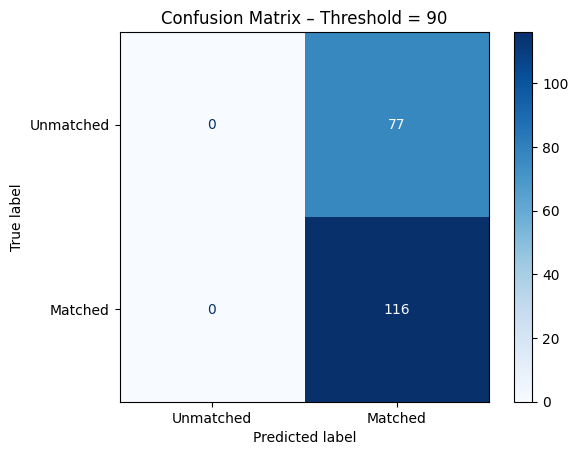


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.60      1.00      0.75       116

    accuracy                           0.60       193
   macro avg       0.30      0.50      0.38       193
weighted avg       0.36      0.60      0.45       193



C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

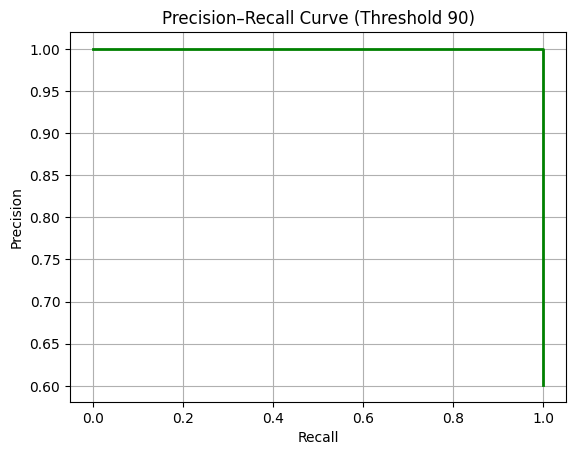

In [19]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Load your dataset ---
df = pd.read_excel("mergedrowsonly_fuzzy_thresholdnew_90.xlsx")

# --- 2. Define predicted label ---
# 1 = Matched, 0 = Unmatched
df["predicted"] = (df["MIN_FUZZY"] >= 90).astype(int)

# --- 3. Define actual (manual) label ---
# Make sure the column name matches your file (e.g., "Manual" or "y_true")
y_true = df["MANUAL_CHECK"]
y_pred = df["predicted"]

# --- 4. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Unmatched", "Matched"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Threshold = 90")
plt.show()

# --- 5. Print classification report ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=2))

# --- 6. Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_true, df["MIN_FUZZY"])

plt.plot(recall, precision, color="green", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Threshold 90)")
plt.grid(True)
plt.show()


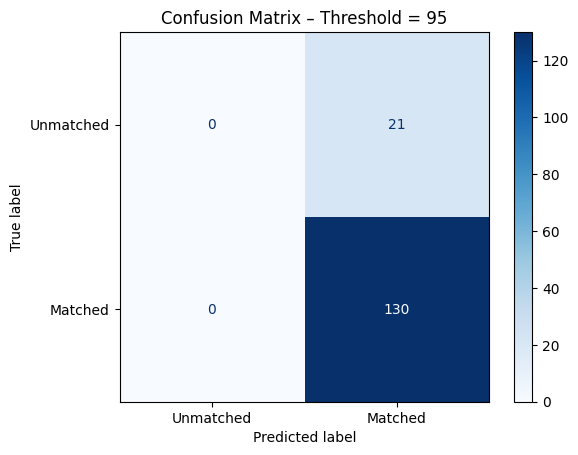


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.86      1.00      0.93       130

    accuracy                           0.86       151
   macro avg       0.43      0.50      0.46       151
weighted avg       0.74      0.86      0.80       151



C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

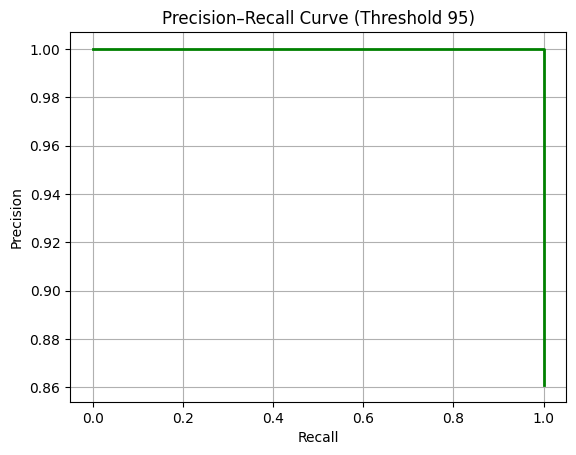

In [23]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Load your dataset ---
df = pd.read_excel("mergedrowsonly_fuzzy_thresholdnew_95.xlsx")

# --- 2. Define predicted label ---
# 1 = Matched, 0 = Unmatched
df["predicted"] = (df["MIN_FUZZY"] >= 95).astype(int)

# --- 3. Define actual (manual) label ---
# Make sure the column name matches your file (e.g., "Manual" or "y_true")
y_true = df["MANUAL_CHECK"]
y_pred = df["predicted"]

# --- 4. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Unmatched", "Matched"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Threshold = 95")
plt.show()

# --- 5. Print classification report ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=2))

# --- 6. Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_true, df["MIN_FUZZY"])

plt.plot(recall, precision, color="green", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Threshold 95)")
plt.grid(True)
plt.show()


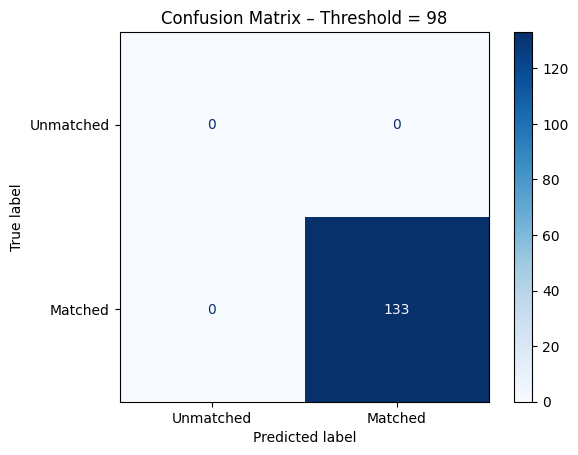


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       133

    accuracy                           1.00       133
   macro avg       1.00      1.00      1.00       133
weighted avg       1.00      1.00      1.00       133



In [26]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Load your dataset ---
df = pd.read_excel("C:\\Users\\USER\\Desktop\\Data cleaning (NLP)\\fuzzy\\mergedrowsonly_fuzzy_thresholdnew_98.xlsx")

# --- 2. Define predicted label ---
# 1 = Matched, 0 = Unmatched
df["predicted"] = (df["MIN_FUZZY"] >= 98).astype(int)

# --- 3. Define actual (manual) label ---
# Make sure the column name matches your file (e.g., "Manual" or "y_true")

# y_true and y_pred
y_true = df["MANUAL_CHECK"]
y_pred = df["predicted"]

# Include all labels explicitly: 0 = Unmatched, 1 = Matched
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(cm, display_labels=["Unmatched", "Matched"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Threshold = 98")
plt.show()

# --- 5. Print classification report ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=2))

# THRESHOLD VALIDATION BEFORE RUN THE PIPELINE TO CHOOSE THE BETTER THRESHOLD

# 20 rows manually validated dataset
# OPTIMAL THRESHOLD VALIDATION using YOUDEN'S INDEX

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


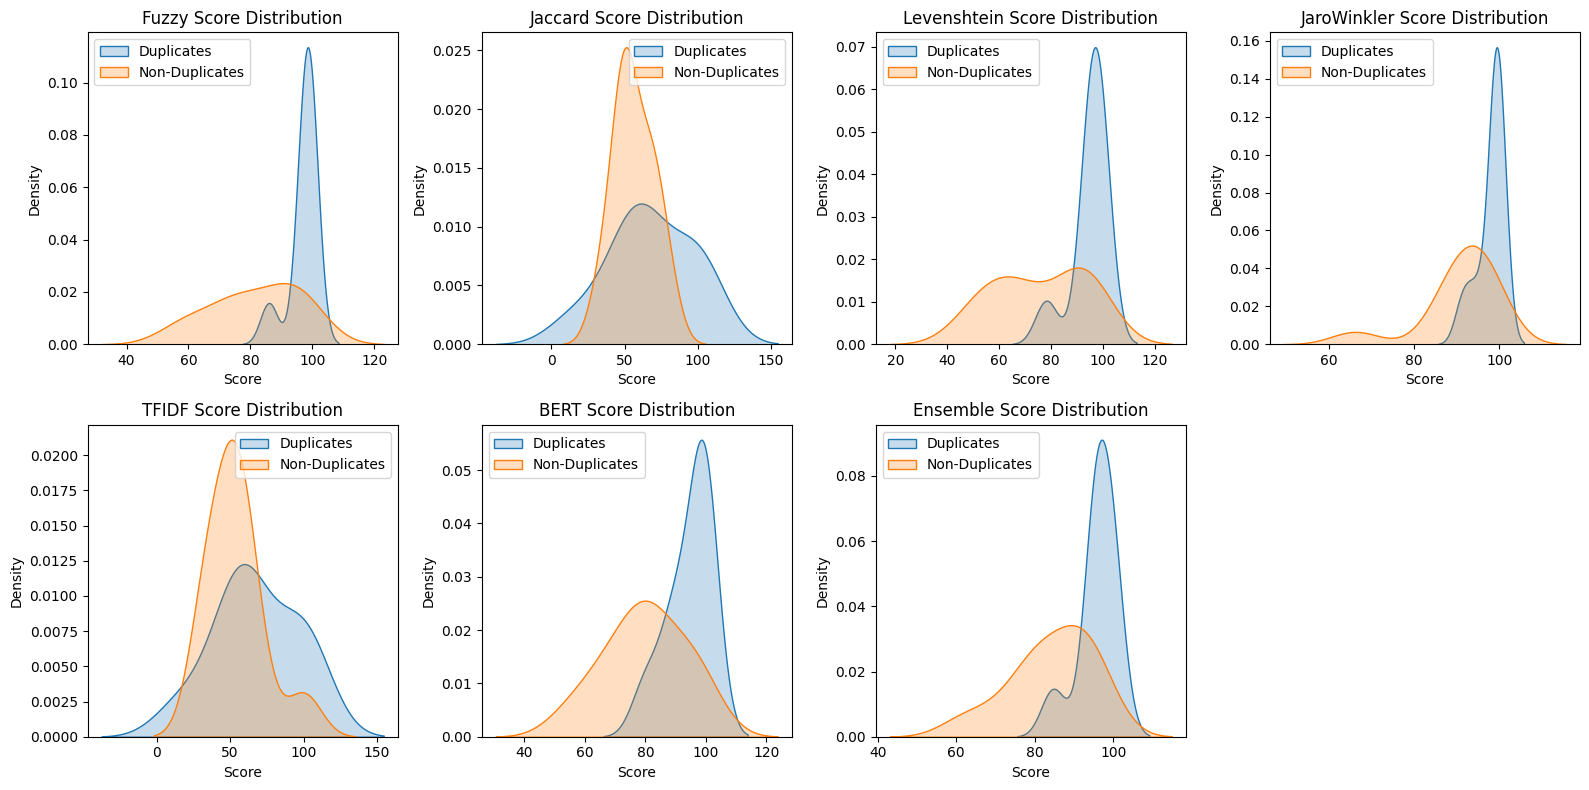

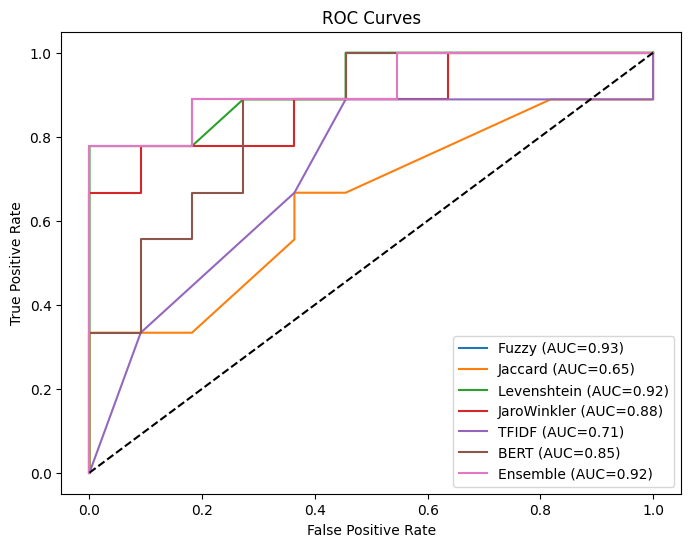

Optimal thresholds based on Youden's Index and F1 maximization:

Model: Fuzzy
  - Optimal Threshold (Youden): 98.000
  - Best F1 Threshold: 98.000
  - Max F1 Score: 0.875

Model: Jaccard
  - Optimal Threshold (Youden): 100.000
  - Best F1 Threshold: 60.000
  - Max F1 Score: 0.632

Model: Levenshtein
  - Optimal Threshold (Youden): 95.238
  - Best F1 Threshold: 95.238
  - Max F1 Score: 0.875

Model: JaroWinkler
  - Optimal Threshold (Youden): 98.431
  - Best F1 Threshold: 98.431
  - Max F1 Score: 0.824

Model: TFIDF
  - Optimal Threshold (Youden): 51.015
  - Best F1 Threshold: 51.015
  - Max F1 Score: 0.727

Model: BERT
  - Optimal Threshold (Youden): 87.759
  - Best F1 Threshold: 87.759
  - Max F1 Score: 0.800

Model: Ensemble
  - Optimal Threshold (Youden): 95.730
  - Best F1 Threshold: 95.730
  - Max F1 Score: 0.875


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from fuzzywuzzy import fuzz
from Levenshtein import distance as levenshtein_distance, jaro_winkler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
import os
from datetime import datetime
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, f1_score

# -----------------------------
# Helper function: Normalize name
# -----------------------------
def normalize_name(name):
    """Normalize name for comparison"""
    if pd.isna(name):
        return ""
    return str(name).lower().strip()


# -----------------------------
# Individual similarity functions - ALL RETURN 0-100 SCALE
# -----------------------------
def fuzzy_similarity(name1, name2):
    """Return fuzzy similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    return fuzz.ratio(n1, n2)  # Already 0-100

def levenshtein_similarity(name1, name2):
    """Return Levenshtein similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    distance = levenshtein_distance(n1, n2)
    max_len = max(len(n1), len(n2))
    
    if max_len == 0:
        return 0.0
    
    # Convert 0-1 to 0-100
    return (1 - (distance / max_len)) * 100

def jaccard_similarity(name1, name2):
    """Return Jaccard similarity score (0-100)"""
    n1 = set(normalize_name(name1).split())
    n2 = set(normalize_name(name2).split())
    
    if not n1 or not n2:
        return 0.0
    
    # Convert 0-1 to 0-100
    return (len(n1.intersection(n2)) / len(n1.union(n2))) * 100

def jaro_winkler_similarity(name1, name2):
    """Return Jaro-Winkler similarity score (0-100)"""
    n1, n2 = normalize_name(name1), normalize_name(name2)
    # Convert 0-1 to 0-100
    return jaro_winkler(n1, n2) * 100

def tfidf_cosine_similarity(name1, name2):
    """Return TF-IDF cosine similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    tfidf = TfidfVectorizer().fit([n1, n2])
    vectors = tfidf.transform([n1, n2])
    
    score = cosine_similarity(vectors[0], vectors[1])[0][0]
    # Convert 0-1 to 0-100
    return score * 100

# Initialize BERT model
try:
    bert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    BERT_AVAILABLE = True
except Exception as e:
    print(f"⚠️ BERT model not available: {e}")
    print("⚠️ Continuing without BERT similarity...")
    BERT_AVAILABLE = False

def bert_similarity(name1, name2):
    """Return BERT cosine similarity score (0-100)"""
    if not BERT_AVAILABLE:
        return 0.0
    
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    embeddings = bert_model.encode([n1, n2])
    similarity = np.dot(embeddings[0], embeddings[1]) / (
        np.linalg.norm(embeddings[0]) * np.linalg.norm(embeddings[1])
    )
    
    # Convert 0-1 to 0-100
    return float(similarity) * 100

# -----------------------------
# Ensemble scoring - ALL INPUTS ARE 0-100
# -----------------------------
def ensemble_score(fz, jc, lev, jw, tfidf, bert):
    """Calculate weighted ensemble score (0-100)"""
    # All inputs are already 0-100 scale
    return round(
        (fz * 0.45) +
        (jw * 0.45) +
        ((tfidf+bert)/2) * 0.10,2
    )

# Load your labeled validation dataset
validation_file = "C:\\Users\\USER\\Desktop\\Data cleaning (NLP)\\threshold validation.xlsx"  #update this path
df_val = pd.read_excel(validation_file)

# Ensure your columns are correctly named
# Example: 'E NAME1', 'E NAME2', 'E NO1', 'E NO2', 'Label'

# Initialize lists to store scores
fz_scores = []
jc_scores = []
lev_scores = []
jw_scores = []
tfidf_scores = []
bert_scores = []
ensemble_scores = []
true_labels = []

# Loop through pairs to compute scores
for idx, row in df_val.iterrows():
    name1 = row['E NAME1']
    name2 = row['E NAME2']
    label = row['Label']
    # Compute scores
    fz = fuzzy_similarity(name1, name2)
    jc = jaccard_similarity(name1, name2)
    lev = levenshtein_similarity(name1, name2)
    jw = jaro_winkler_similarity(name1, name2)
    tfidf = tfidf_cosine_similarity(name1, name2)
    bert = bert_similarity(name1, name2)
    ens = ensemble_score(fz, jc, lev, jw, tfidf, bert)

    # Append to lists
    fz_scores.append(fz)
    jc_scores.append(jc)
    lev_scores.append(lev)
    jw_scores.append(jw)
    tfidf_scores.append(tfidf)
    bert_scores.append(bert)
    ensemble_scores.append(ens)
    true_labels.append(label)

# Convert to numpy arrays for analysis
scores_dict = {
    'Fuzzy': np.array(fz_scores),
    'Jaccard': np.array(jc_scores),
    'Levenshtein': np.array(lev_scores),
    'JaroWinkler': np.array(jw_scores),
    'TFIDF': np.array(tfidf_scores),
    'BERT': np.array(bert_scores),
    'Ensemble': np.array(ensemble_scores)
}

# Function to find optimal threshold using Youden's Index
def find_best_threshold(scores, labels):
    fpr, tpr, thresholds = roc_curve(labels, scores)
    # Youden's index
    youden_idx = np.argmax(tpr - fpr)
    optimal_thresh = thresholds[youden_idx]
    # Also compute F1 at various thresholds
    f1_scores = []
    for thresh in thresholds:
        preds = (scores >= thresh).astype(int)
        f1 = f1_score(labels, preds)
        f1_scores.append(f1)
    max_f1_idx = np.argmax(f1_scores)
    best_f1_thresh = thresholds[max_f1_idx]
    return optimal_thresh, best_f1_thresh, f1_scores[max_f1_idx], fpr, tpr

# Analyze each model
results = {}
for model_name, scores in scores_dict.items():
    optimal_thresh, best_f1_thresh, max_f1, fpr, tpr = find_best_threshold(scores, true_labels)
    results[model_name] = {
        'Optimal Threshold (Youden)': optimal_thresh,
        'Best F1 Threshold': best_f1_thresh,
        'Max F1 Score': max_f1,
        'FPR': fpr,
        'TPR': tpr
    }

# Plot score distributions
plt.figure(figsize=(16, 8))
for i, (model_name, scores) in enumerate(scores_dict.items()):
    plt.subplot(2, 4, i+1)
    sns.kdeplot(scores[ np.array(true_labels)==1 ], label='Duplicates', fill=True)
    sns.kdeplot(scores[ np.array(true_labels)==0 ], label='Non-Duplicates', fill=True)
    plt.title(f'{model_name} Score Distribution')
    plt.xlabel('Score')
    plt.legend()

plt.tight_layout()
plt.show()

# Plot ROC curves
plt.figure(figsize=(8,6))
for model_name, res in results.items():
    plt.plot(res['FPR'], res['TPR'], label=f"{model_name} (AUC={roc_auc_score(true_labels, scores_dict[model_name]):.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Output results
print("Optimal thresholds based on Youden's Index and F1 maximization:")
for model_name, res in results.items():
    print(f"\nModel: {model_name}")
    print(f"  - Optimal Threshold (Youden): {res['Optimal Threshold (Youden)']:.3f}")
    print(f"  - Best F1 Threshold: {res['Best F1 Threshold']:.3f}")
    print(f"  - Max F1 Score: {res['Max F1 Score']:.3f}")

# Save results to a CSV
thresholds_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Optimal Threshold (Youden)': [res['Optimal Threshold (Youden)'] for res in results.values()],
    'Best F1 Threshold': [res['Best F1 Threshold'] for res in results.values()],
    'Max F1 Score': [res['Max F1 Score'] for res in results.values()]
})
thresholds_df.to_csv('best_thresholds_results.csv', index=False)

# ENSEMBLE VALIDATION TRIALS

In [25]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from fuzzywuzzy import fuzz
from Levenshtein import distance as levenshtein_distance, jaro_winkler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
import os
from datetime import datetime
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, f1_score

# -----------------------------
# Helper function: Normalize name
# -----------------------------
def normalize_name(name):
    """Normalize name for comparison"""
    if pd.isna(name):
        return ""
    return str(name).lower().strip()


# -----------------------------
# Individual similarity functions - ALL RETURN 0-100 SCALE
# -----------------------------
def fuzzy_similarity(name1, name2):
    """Return fuzzy similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    return fuzz.ratio(n1, n2)  # Already 0-100

def levenshtein_similarity(name1, name2):
    """Return Levenshtein similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    distance = levenshtein_distance(n1, n2)
    max_len = max(len(n1), len(n2))
    
    if max_len == 0:
        return 0.0
    
    # Convert 0-1 to 0-100
    return (1 - (distance / max_len)) * 100

def jaccard_similarity(name1, name2):
    """Return Jaccard similarity score (0-100)"""
    n1 = set(normalize_name(name1).split())
    n2 = set(normalize_name(name2).split())
    
    if not n1 or not n2:
        return 0.0
    
    # Convert 0-1 to 0-100
    return (len(n1.intersection(n2)) / len(n1.union(n2))) * 100

def jaro_winkler_similarity(name1, name2):
    """Return Jaro-Winkler similarity score (0-100)"""
    n1, n2 = normalize_name(name1), normalize_name(name2)
    # Convert 0-1 to 0-100
    return jaro_winkler(n1, n2) * 100

def tfidf_cosine_similarity(name1, name2):
    """Return TF-IDF cosine similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    tfidf = TfidfVectorizer().fit([n1, n2])
    vectors = tfidf.transform([n1, n2])
    
    score = cosine_similarity(vectors[0], vectors[1])[0][0]
    # Convert 0-1 to 0-100
    return score * 100

# Initialize BERT model
try:
    bert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    BERT_AVAILABLE = True
except Exception as e:
    print(f"⚠️ BERT model not available: {e}")
    print("⚠️ Continuing without BERT similarity...")
    BERT_AVAILABLE = False

def bert_similarity(name1, name2):
    """Return BERT cosine similarity score (0-100)"""
    if not BERT_AVAILABLE:
        return 0.0
    
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    embeddings = bert_model.encode([n1, n2])
    similarity = np.dot(embeddings[0], embeddings[1]) / (
        np.linalg.norm(embeddings[0]) * np.linalg.norm(embeddings[1])
    )
    
    # Convert 0-1 to 0-100
    return float(similarity) * 100

# -----------------------------
# Ensemble scoring - ALL INPUTS ARE 0-100
# -----------------------------
def ensemble_score(fz, jc, lev, jw, tfidf, bert):
    """Calculate weighted ensemble score (0-100)"""
    # All inputs are already 0-100 scale
    return round(
        (fz * 0.70) +
        (jw * 0.20) +
        ((tfidf+bert)/2) * 0.10,2
    )

ensemble_scores = []

for idx, row in df_val.iterrows():
    name1 = row['E NAME1']
    name2 = row['E NAME2']
    label = row['Label']
    
    # Compute individual similarity scores
    fz = fuzzy_similarity(name1, name2)
    jc = jaccard_similarity(name1, name2)
    lev = levenshtein_similarity(name1, name2)
    jw = jaro_winkler_similarity(name1, name2)
    tfidf = tfidf_cosine_similarity(name1, name2)
    bert = bert_similarity(name1, name2)
    
    # Compute ensemble score
    ens = ensemble_score(fz, jc, lev, jw, tfidf, bert)
    ensemble_scores.append(ens)
    
    # Store all scores and label for validation
    validation_results.append({
        'E_NAME1': name1,
        'E_NAME2': name2,
        'Label': label,
        'Fuzzy': fz,
        'Jaccard': jc,
        'Levenshtein': lev,
        'Jaro_Winkler': jw,
        'TFIDF_Cosine': tfidf,
        'BERT': bert,
        'Ensemble': ens
    })

# Convert to DataFrame for analysis
validation_df = pd.DataFrame(validation_results)

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [26]:
top_pairs = validation_df.sort_values(by='Ensemble', ascending=False).head(5)
print(top_pairs)

                     E_NAME1                   E_NAME2  Label  Fuzzy  Jaccard  \
16     Y HAIR DRESING SALOON     Y HAIR DRESING SALOON      1    100    100.0   
75  A1 FRESH PRODUCE SDN BHD  A1 FRESH PRODUCE SDN BHD      1    100    100.0   
36     Y HAIR DRESING SALOON     Y HAIR DRESING SALOON      1    100    100.0   
35  A1 FRESH PRODUCE SDN BHD  A1 FRESH PRODUCE SDN BHD      1    100    100.0   
76     Y HAIR DRESING SALOON     Y HAIR DRESING SALOON      1    100    100.0   

    Levenshtein  Jaro_Winkler  TFIDF_Cosine   BERT  Ensemble  
16        100.0         100.0         100.0  100.0     100.0  
75        100.0         100.0         100.0  100.0     100.0  
36        100.0         100.0         100.0  100.0     100.0  
35        100.0         100.0         100.0  100.0     100.0  
76        100.0         100.0         100.0  100.0     100.0  


In [11]:
top_pairs = validation_df.sort_values(by='Ensemble', ascending=False).tail(5)
print(top_pairs)

                                       E_NAME1                     E_NAME2  \
13  A T INDUSTRIES ENTERPRISE MALAYSIA SDN BHD   A T INDUSTRIES ENTERPRISE   
8                                96 HAIR SALON              96 HAIR STUDIO   
12                  A MILLION SCOVILLE SDN BHD   A MILLION DEGREES SDN BHD   
19                        A YOGURT COW SDN BHD  A YOGURT COW PG ENTERPRISE   
17                A5 SECURITY SERVICES SDN BHD    A5 MANUFACTURING SDN BHD   

    Label  Fuzzy    Jaccard  Levenshtein  Jaro_Winkler  TFIDF_Cosine  \
13      0     75  57.142857    59.523810     91.904762     50.232878   
8       0     74  50.000000    64.285714     89.670330     50.310261   
12      0     75  66.666667    69.230769     87.384615     60.297482   
19      0     61  42.857143    53.846154     87.057692     33.609693   
17      0     58  50.000000    50.000000     66.269841     51.014902   

         BERT  Ensemble  
13  67.329252     80.99  
8   83.829206     80.36  
12  66.225153     79

In [27]:
validation_df.head(5)

,E_NAME1,E_NAME2,Label,Fuzzy,Jaccard,Levenshtein,Jaro_Winkler,TFIDF_Cosine,BERT,Ensemble
0,5R TECHONOLOGIES SDNBHD,5R TECHNOLOGY SDN BHD,1,86,16.666667,78.260870,91.459082,17.077611,79.908210,84.71
1,7 SPICES 7MALAYSIA SDN BHD,7 SPICES 7 MALAYSIA SDN BHD,1,98,66.666667,96.296296,94.643875,60.297482,87.759387,94.09
2,707 HOTEL MELAKA SDN BHD,707 HOTEL MELAKA SDNBHD,1,98,50.000000,95.833333,99.166667,51.014902,94.506621,96.00
3,77 SUPPLY HUB SDN BHD,77 SUPPLY HUB SDNBHD,1,98,50.000000,95.238095,99.047619,51.014902,90.069526,95.73
4,8 FOOD JB SDN BHD,8 FOOD JBS SDN BHD,0,97,66.666667,94.444444,97.712418,60.297482,98.977578,95.58


In [28]:
validation_df.tail(5)

,E_NAME1,E_NAME2,Label,Fuzzy,Jaccard,Levenshtein,Jaro_Winkler,TFIDF_Cosine,BERT,Ensemble
95,A1 FRESH PRODUCE SDN BHD,A1 FRESH PRODUCE SDN BHD,1,100,100.000000,100.000000,100.000000,100.000000,100.000000,100.00
96,Y HAIR DRESING SALOON,Y HAIR DRESING SALOON,1,100,100.000000,100.000000,100.000000,100.000000,100.000000,100.00
97,A5 SECURITY SERVICES SDN BHD,A5 MANUFACTURING SDN BHD,0,58,50.000000,50.000000,66.269841,51.014902,78.098643,60.31
98,A WOW ME PV SDN BHD,A WOW ME NS SDN BHD,0,89,71.428571,89.473684,94.613003,66.941885,82.928503,88.72
99,A YOGURT COW SDN BHD,A YOGURT COW PG ENTERPRISE,0,61,42.857143,53.846154,87.057692,33.609693,78.181720,65.70
